# Trend Exploration (2025-10-20)

Quick sanity checks on the exported analytics tables. Run this after `scripts/run_analytics_exports.py` so the Parquet files in `data/analytics/` and `data/analytics/trends/` are fresh.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [9]:
from pathlib import Path

DATA_DIR = Path.cwd().parents[1] / "data" / "analytics"
TREND_DIR = DATA_DIR / "trends"

def _safe_read_parquet(path):
	if not path.exists():
		print(f"File not found: {path!s} — returning empty DataFrame")
		return pd.DataFrame()
	try:
		return pd.read_parquet(path)
	except Exception as exc:
		# Provide a friendly message instead of crashing (e.g. missing parquet engine)
		print(f"Error reading {path!s}: {exc!s} — returning empty DataFrame")
		return pd.DataFrame()

tracks = _safe_read_parquet(DATA_DIR / "tracks.parquet")
song_year_counts = _safe_read_parquet(TREND_DIR / "song_year_counts.parquet")
set_duration_summary = _safe_read_parquet(TREND_DIR / "set_duration_summary.parquet")
intro_outro_counts = _safe_read_parquet(TREND_DIR / "intro_outro_counts.parquet")

tracks.head()

,track_id,show_id,show_date,set_label,position,track_title,duration_ms,likes_count,song_id,song_title,song_slug,canonical_set,song_effective_title,duration_seconds,era,year
0,38579,1324,1983-12-02,1,1,Long Cool Woman in a Black Dress,0,0,461,Long Cool Woman in a Black Dress,long-cool-woman-in-a-black-dress,set1,Long Cool Woman in a Black Dress,0.0,1.0,1983
1,38580,1324,1983-12-02,1,2,Proud Mary,0,0,601,Proud Mary,proud-mary,set1,Proud Mary,0.0,1.0,1983
2,38581,1324,1983-12-02,1,3,In the Midnight Hour,0,0,400,In the Midnight Hour,in-the-midnight-hour,set1,In the Midnight Hour,0.0,1.0,1983
3,38582,1324,1983-12-02,1,4,Squeeze Box,0,0,1131,Squeeze Box,squeeze-box,set1,Squeeze Box,0.0,1.0,1983
4,38583,1324,1983-12-02,1,5,Roadhouse Blues,0,0,1132,Roadhouse Blues,roadhouse-blues,set1,Roadhouse Blues,0.0,1.0,1983


## Top Songs by Year

Inspect the highest-played songs for a selected year.

/var/folders/xz/_rspsrgd6sv24mbtqq4_pnw40000gn/T/ipykernel_44243/1940685163.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_year, x="play_count", y="song_effective_title", palette="viridis")


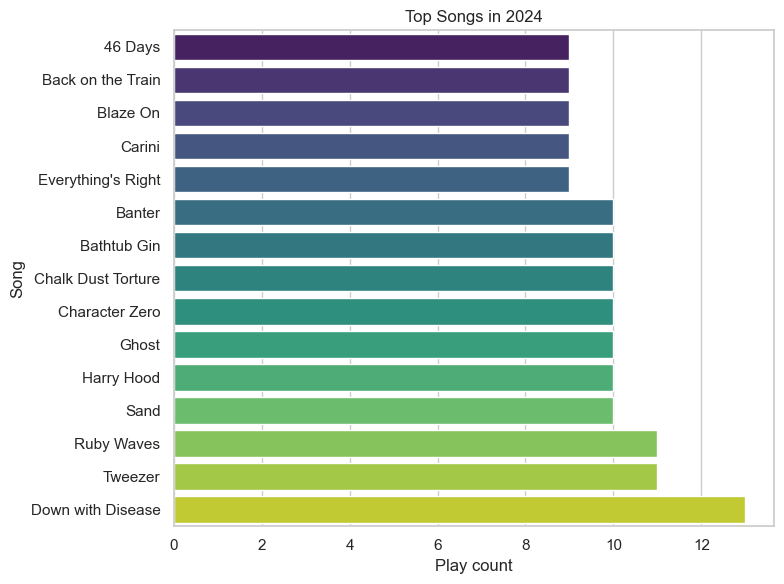

In [10]:
year = 2024

top_year = (
    song_year_counts.loc[song_year_counts["year"] == year]
    .nlargest(15, "play_count")
    .sort_values("play_count", ascending=True)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_year, x="play_count", y="song_effective_title", palette="viridis")
plt.title(f"Top Songs in {year}")
plt.xlabel("Play count")
plt.ylabel("Song")
plt.tight_layout()
plt.show()

## Set Duration Trends

Look at how total set durations evolve over time.

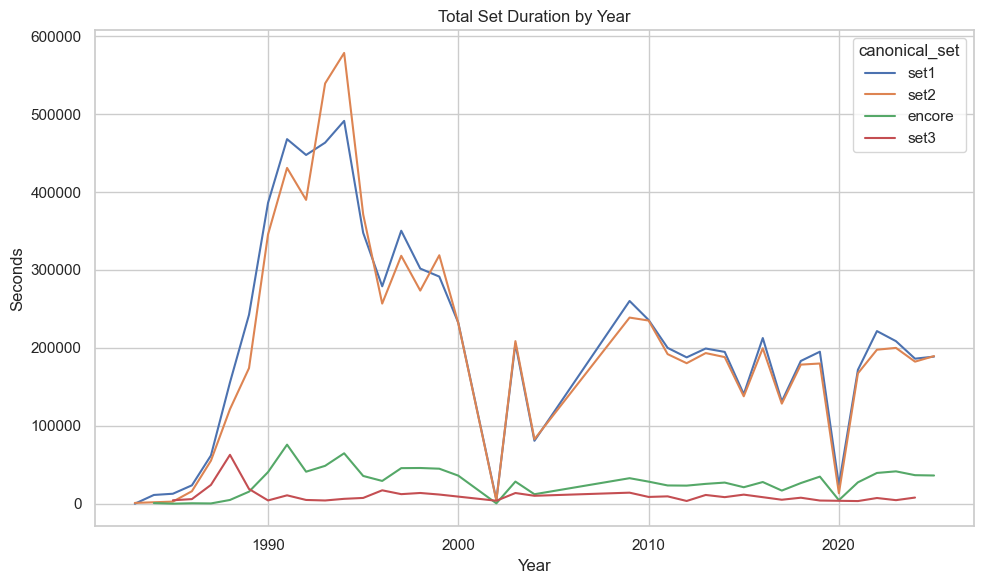

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=set_duration_summary,
    x="year",
    y="total_duration_seconds",
    hue="canonical_set",
)
plt.title("Total Set Duration by Year")
plt.ylabel("Seconds")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

## Intros and Outros

Check which songs commonly open or close sets in the modern era.

/var/folders/xz/_rspsrgd6sv24mbtqq4_pnw40000gn/T/ipykernel_44243/2035495828.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recent_intros, x="appearances", y="song", palette="magma")


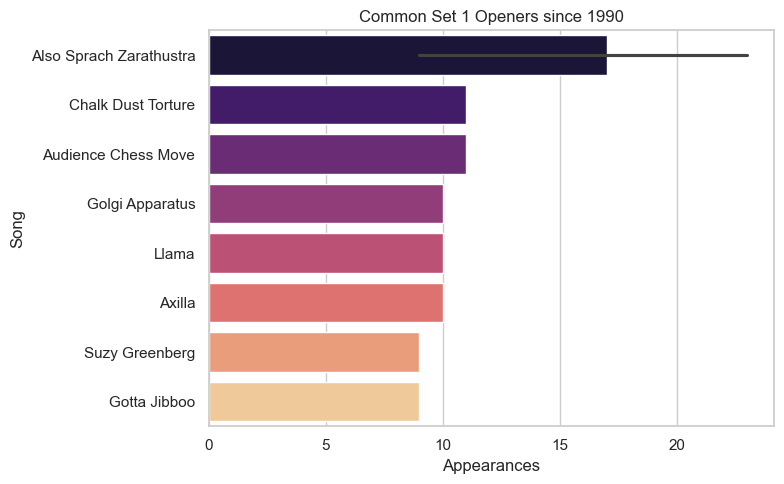

In [ ]:
recent_threshold = 1990

recent_intros = (
    intro_outro_counts
    .query("year >= @recent_threshold and type == 'intro' and canonical_set == 'set2'")
    .nlargest(10, "appearances")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=recent_intros, x="appearances", y="song", palette="magma")
plt.title(f"Common Set 2 Openers since {recent_threshold}")
plt.xlabel("Appearances")
plt.ylabel("Song")
plt.tight_layout()
plt.show()